<a href="https://colab.research.google.com/github/arnavd371/Saddle-Escape-Efficiency/blob/main/Saddle_EE_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Locating and verifying saddles...
  Himmelblau: 3 saddle(s); using [-0.128 -1.954]  lambda_min=-50.61  r_curv=0.141
  Ackley: 3 saddle(s); using [-0.577  0.875]  lambda_min=-17.11  r_curv=0.242
  Rastrigin: 3 saddle(s); using [ 0.503 -0.   ]  lambda_min=-392.73  r_curv=0.050
  Styblinski: 3 saddle(s); using [0.157 2.747]  lambda_min=-15.85  r_curv=0.251
  Levy: 3 saddle(s); using [ 1.    -2.257]  lambda_min=-2.96  r_curv=0.582

Running all configs (one trajectory set, four criterion families)...
  Himmelblau done.
  Ackley done.
  Rastrigin done.
  Styblinski done.
  Levy done.

SEE at lr=0.2  (A_fixed-r / B_curvature / C_eigendisp / D_loss)

Himmelblau:
  GD_fixed : 0.478±0.015 / 0.422±0.017 / 0.881±0.041 / 0.075±0.027
  Adam     : 0.102±0.001 / 0.064±0.003 / 1.000±0.000 / 0.064±0.003
  RMSProp  : 1.000±0.000 / 0.442±0.015 / 1.000±0.000 / 0.442±0.014
  AdaGrad  : 0.062±0.000 / 0.050±0.000 / 1.000±0.000 / 0.050±0.000

Ackley:
  GD_fixed : 0.073±0.007 / 0.129±0.017 / 0.629±0.048 / 0.110

/tmp/ipykernel_815/3869754383.py:173: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho=stats.spearmanr(a,b).correlation
/tmp/ipykernel_815/3869754383.py:177: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  f"A-C:{stats.spearmanr(a['A'],a['C']).correlation:+.2f} "
/tmp/ipykernel_815/3869754383.py:198: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r1=stats.spearmanr(rank[ps[0]],rank[ps[-1]]).correlation


  family D: mean rho(extreme thresholds) = +0.91 over 5 functions


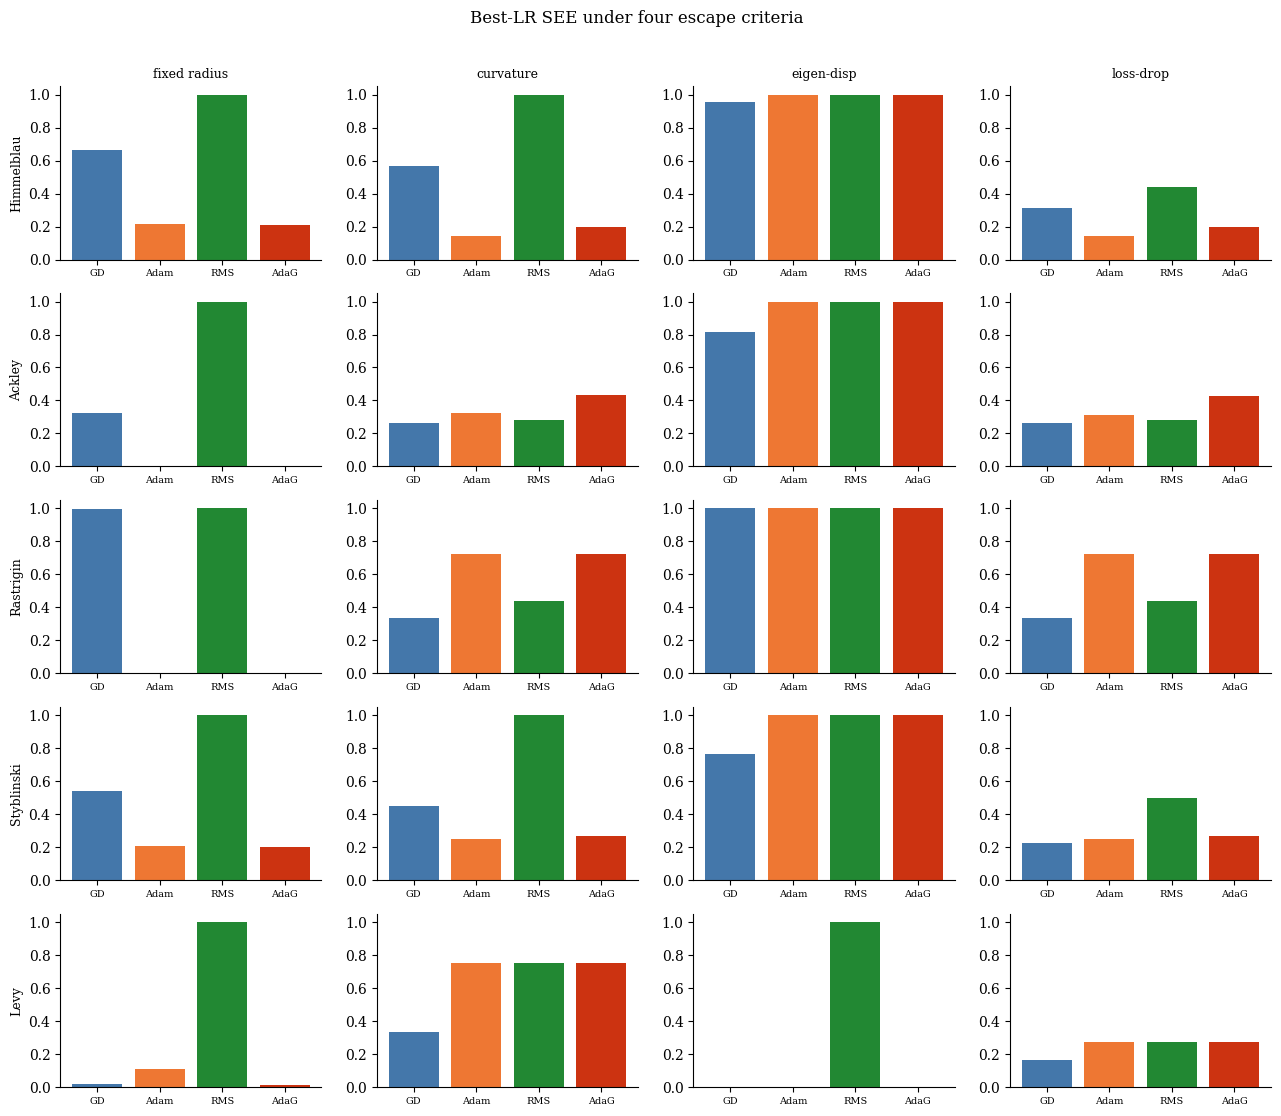

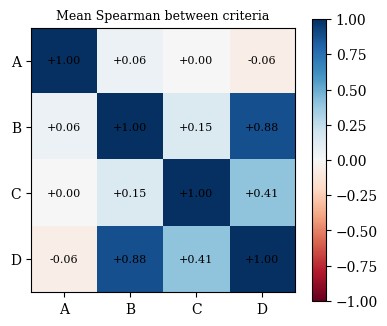


All CSVs and figures in results_final/. Paste the printed blocks back here.


In [1]:
import torch, numpy as np, pandas as pd, os
from scipy import stats, optimize
import matplotlib; matplotlib.rcParams['font.family']='serif'
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)
os.makedirs('results_final', exist_ok=True)
SEED=42; N=200; TMAX=200
LRS=[0.001,0.01,0.05,0.1,0.2,0.5]; OPTS=['GD_fixed','Adam','RMSProp','AdaGrad']
rng=np.random.default_rng(SEED)

#  batched functions: X is (n,2)
def F_himmelblau(X): return (X[:,0]**2+X[:,1]-11)**2+(X[:,0]+X[:,1]**2-7)**2
def F_ackley(X):
    a,b,c=20.,0.2,2*np.pi
    return -a*torch.exp(-b*torch.sqrt((X**2).mean(1)))-torch.exp(torch.cos(c*X).mean(1))+a+np.e
def F_rastrigin(X): return 20+(X**2-10*torch.cos(2*np.pi*X)).sum(1)
def F_styblinski(X): return 0.5*(X**4-16*X**2+5*X).sum(1)
def F_levy(X):
    W=1+(X-1)/4
    return (torch.sin(np.pi*W[:,0])**2+(W[:,0]-1)**2*(1+10*torch.sin(np.pi*W[:,0]+1)**2)
            +(W[:,1]-1)**2*(1+torch.sin(2*np.pi*W[:,1])**2))
FUNCS={'Himmelblau':F_himmelblau,'Ackley':F_ackley,'Rastrigin':F_rastrigin,
       'Styblinski':F_styblinski,'Levy':F_levy}
DOM={'Himmelblau':6.,'Ackley':5.,'Rastrigin':5.12,'Styblinski':5.,'Levy':8.}

def bgrad(F,X):
    X=X.detach().clone().requires_grad_(True); F(X).sum().backward(); return X.grad.detach()
def beigs(F,X,h=1e-4):  # batched 2x2 Hessian eigs by central differences of grad
    e1=torch.tensor([h,0.]); e2=torch.tensor([0.,h])
    gx1=bgrad(F,X+e1); gx2=bgrad(F,X-e1); gy1=bgrad(F,X+e2); gy2=bgrad(F,X-e2)
    Hxx=(gx1[:,0]-gx2[:,0])/(2*h); Hyy=(gy1[:,1]-gy2[:,1])/(2*h)
    Hxy=((gx1[:,1]-gx2[:,1])/(2*h)+(gy1[:,0]-gy2[:,0])/(2*h))/2
    m=(Hxx+Hyy)/2; d=torch.sqrt(((Hxx-Hyy)/2)**2+Hxy**2)
    return m-d, m+d, Hxx, Hxy, Hyy

#  robust saddle finder: rank-based candidates + fsolve + verification
def find_saddles(F,L,grid=240,n_cand=800,keep=3):
    xs=np.linspace(-L,L,grid)
    G=torch.tensor(np.stack(np.meshgrid(xs,xs),-1).reshape(-1,2))
    gn=bgrad(F,G).norm(dim=1).numpy()
    cand=G[np.argsort(gn)[:n_cand]].numpy()
    def gf(p):
        x=torch.tensor(p)[None].requires_grad_(True); F(x).sum().backward()
        return x.grad[0].numpy()
    found=[]
    for p0 in cand:
        try: sol,info,ier,_=optimize.fsolve(gf,p0,full_output=True)
        except Exception: continue
        if ier!=1 or np.abs(sol).max()>L or np.linalg.norm(gf(sol))>1e-6: continue
        lmin,lmax,*_=beigs(F,torch.tensor(sol)[None])
        if lmin.item()<-1e-4 and lmax.item()>1e-4:
            if all(np.linalg.norm(sol-q)>0.3 for q in found): found.append(sol)
    found.sort(key=lambda s:np.linalg.norm(s))
    return [torch.tensor(s) for s in found[:keep]]

print('Locating and verifying saddles...')
SAD={}; GEOM={}
for n,F in FUNCS.items():
    ss=find_saddles(F,DOM[n]); SAD[n]=ss
    if not ss: print(f'  {n}: NONE -> excluded'); continue
    s=ss[0]; lmin,lmax,Hxx,Hxy,Hyy=beigs(F,s[None])
    lmin=lmin.item()
    v=torch.tensor([lmin-Hyy.item(),Hxy.item()]) if abs(Hxy.item())>1e-12 else torch.tensor([1.,0.])
    v=v/v.norm(); r_curv=1/np.sqrt(abs(lmin)); f_s=F(s[None])[0].item()
    GEOM[n]=(s,v,r_curv,f_s,lmin)
    print(f'  {n}: {len(ss)} saddle(s); using {s.numpy().round(3)}  lambda_min={lmin:.2f}  r_curv={r_curv:.3f}')
FUNCS={k:v for k,v in FUNCS.items() if SAD.get(k)}

def make_opt(nm,P,lr):
    if nm=='GD_fixed': return torch.optim.SGD([P],lr=lr)
    if nm=='Adam':     return torch.optim.Adam([P],lr=lr)
    if nm=='RMSProp':  return torch.optim.RMSprop([P],lr=lr,alpha=0.99)
    if nm=='AdaGrad':  return torch.optim.Adagrad([P],lr=lr)

# criterion variants (family, parameter)
VAR=[('A',1.5),('A',2.0),('A',3.0),          # fixed radius ||x-xs||>r
     ('B',1e-2),('B',1e-3),('B',1e-4),       # curvature lmin>-eps
     ('C',0.5),('C',1.0),('C',2.0),          # |proj on v_esc| > c*r_curv
     ('D',0.25),('D',0.5),('D',1.0)]         # f<f_s-delta AND lmin>-1e-3
HEAD={'A':2.0,'B':1e-3,'C':1.0,'D':0.5}      # headline parameter per family

def run_config(F,geom,opt_nm,lr):
    s,v,r_curv,f_s,_=geom
    torch.manual_seed(SEED)
    X=(s[None]+0.1*torch.randn(N,2)).requires_grad_(True)
    opt=make_opt(opt_nm,X,lr)
    esc={k:np.zeros(N,bool) for k in range(len(VAR))}
    stp={k:np.full(N,TMAX+1) for k in range(len(VAR))}
    for t in range(TMAX):
        opt.zero_grad(); F(X).sum().backward(); opt.step()
        Xd=X.detach().clone()
        Xd=torch.nan_to_num(Xd,nan=1e6,posinf=1e6,neginf=-1e6)
        # compute outside no_grad
        lmin,_,_,_,_=beigs(F,Xd); lmin=lmin.numpy()
        fv=F(Xd).numpy()
        with torch.no_grad():
            dist=(Xd-s).norm(dim=1).numpy()
            proj=torch.abs((Xd-s)@v).numpy()
        for k,(fam,p) in enumerate(VAR):
            if fam=='A': cond=dist>p
            elif fam=='B': cond=lmin>-p
            elif fam=='C': cond=proj>p*r_curv
            else: cond=(fv<f_s-p)&(lmin>-1e-3)
            new=(~esc[k])&cond; stp[k][new]=t+1; esc[k]|=new
    return esc,stp

def see_pt(e,s): return (e.mean()/s[e].mean()) if e.any() else 0.0
def see_ci(e,s,B=2000):
    idx=rng.integers(0,N,(B,N)); E=e[idx]; S=s[idx]
    cnt=E.sum(1); tau=np.where(cnt>0,np.where(E,S,0).sum(1)/np.maximum(cnt,1),np.nan)
    vals=np.where(cnt>0,E.mean(1)/tau,0.0)
    lo,hi=np.percentile(vals,[2.5,97.5]); return see_pt(e,s),(hi-lo)/2

print('\nRunning all configs (one trajectory set, four criterion families)...')
DATA={}   # DATA[(fn,opt,lr)][var_idx] = (esc,stp)
for fn,F in FUNCS.items():
    for o in OPTS:
        for lr in LRS:
            e,s=run_config(F,GEOM[fn],o,lr); DATA[(fn,o,lr)]=(e,s)
    print(f'  {fn} done.')

def headline_idx(fam): return VAR.index((fam,HEAD[fam]))
FAMS=['A','B','C','D']

# main cross-criterion table at lr=0.2 and at per-optimizer best LR
rows=[]
print('\nSEE at lr=0.2  (A_fixed-r / B_curvature / C_eigendisp / D_loss)')
for fn in FUNCS:
    print(f'\n{fn}:')
    for o in OPTS:
        e,s=DATA[(fn,o,0.2)]; vals=[]
        for fam in FAMS:
            k=headline_idx(fam); v,ci=see_ci(e[k],s[k]); vals.append((v,ci))
        rows.append({'function':fn,'optimizer':o,**{f'SEE_{f}':v for f,(v,_) in zip(FAMS,vals)},
                     **{f'CI_{f}':c for f,(_,c) in zip(FAMS,vals)}})
        print(f'  {o:9s}: '+' / '.join(f'{v:.3f}±{c:.3f}' for v,c in vals))
pd.DataFrame(rows).to_csv('results_final/main_lr02.csv',index=False)

print('\nSEE at each optimizer\'s BEST LR per criterion ')
best_rows=[]
for fn in FUNCS:
    print(f'\n{fn}:')
    for o in OPTS:
        vals=[]
        for fam in FAMS:
            k=headline_idx(fam)
            v=max(see_pt(*[DATA[(fn,o,lr)][i][k] for i in range(2)]) if False else
                  see_pt(DATA[(fn,o,lr)][0][k],DATA[(fn,o,lr)][1][k]) for lr in LRS)
            vals.append(v)
        best_rows.append({'function':fn,'optimizer':o,**{f'best_{f}':v for f,v in zip(FAMS,vals)}})
        print(f'  {o:9s}: '+' / '.join(f'{v:.3f}' for v in vals))
pd.DataFrame(best_rows).to_csv('results_final/best_lr.csv',index=False)

# winners, rank agreement, Kendall's W
print('\nbest optimizer per criterion ')
for tag,table in [('lr=0.2',rows),('best-LR',best_rows)]:
    print(f'-- {tag} --')
    for fn in FUNCS:
        sub=[r for r in table if r['function']==fn]; line=[]
        for fam in FAMS:
            key=('SEE_' if tag=='lr=0.2' else 'best_')+fam
            line.append(f"{fam}:{max(sub,key=lambda r:r[key])['optimizer']}")
        print(f'  {fn:11s} '+' | '.join(line))

print('\n pairwise Spearman between criteria (best-LR ranks) ')
M=np.zeros((4,4)); cntM=np.zeros((4,4))
for fn in FUNCS:
    sub=[r for r in best_rows if r['function']==fn]
    for i,f1 in enumerate(FAMS):
        for j,f2 in enumerate(FAMS):
            a=[r['best_'+f1] for r in sub]; b=[r['best_'+f2] for r in sub]
            rho=stats.spearmanr(a,b).correlation
            if not np.isnan(rho): M[i,j]+=rho; cntM[i,j]+=1
    a={f:[r['best_'+f] for r in sub] for f in FAMS}
    print(f"  {fn:11s} A-B:{stats.spearmanr(a['A'],a['B']).correlation:+.2f} "
          f"A-C:{stats.spearmanr(a['A'],a['C']).correlation:+.2f} "
          f"A-D:{stats.spearmanr(a['A'],a['D']).correlation:+.2f} "
          f"B-D:{stats.spearmanr(a['B'],a['D']).correlation:+.2f}")
M=M/np.maximum(cntM,1)

print('\nKendall W concordance across the 4 criteria (best-LR)')
for fn in FUNCS:
    sub=[r for r in best_rows if r['function']==fn]
    R=np.array([stats.rankdata([r['best_'+f] for r in sub]) for f in FAMS])  # 4 judges x 4 items
    m,nit=R.shape; S=((R.sum(0)-R.sum()/nit)**2).sum()
    W=12*S/(m**2*(nit**3-nit))
    print(f'  {fn:11s} W={W:.2f}   (1=perfect agreement, 0=none)')

print('\nwithin-family threshold stability (Spearman across variants, best-LR)')
for fam,ps in [('A',[1.5,2.0,3.0]),('B',[1e-2,1e-3,1e-4]),('C',[0.5,1.0,2.0]),('D',[0.25,0.5,1.0])]:
    rhos=[]
    for fn in FUNCS:
        rank={}
        for p in ps:
            k=VAR.index((fam,p))
            rank[p]=[max(see_pt(DATA[(fn,o,lr)][0][k],DATA[(fn,o,lr)][1][k]) for lr in LRS) for o in OPTS]
        r1=stats.spearmanr(rank[ps[0]],rank[ps[-1]]).correlation
        if not np.isnan(r1): rhos.append(r1)
    print(f'  family {fam}: mean rho(extreme thresholds) = {np.mean(rhos):+.2f} over {len(rhos)} functions')

# figures
crit_names={'A':'fixed radius','B':'curvature','C':'eigen-disp','D':'loss-drop'}
fig,axes=plt.subplots(len(FUNCS),4,figsize=(13,2.2*len(FUNCS)),squeeze=False)
for i,fn in enumerate(FUNCS):
    sub=[r for r in best_rows if r['function']==fn]
    for j,fam in enumerate(FAMS):
        ax=axes[i,j]; vals=[r['best_'+fam] for r in sub]
        ax.bar(range(4),vals,color=['#4477aa','#ee7733','#228833','#cc3311'])
        ax.set_xticks(range(4)); ax.set_xticklabels(['GD','Adam','RMS','AdaG'],fontsize=7)
        ax.set_ylim(0,1.05); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if j==0: ax.set_ylabel(fn,fontsize=9)
        if i==0: ax.set_title(crit_names[fam],fontsize=9)
plt.suptitle('Best-LR SEE under four escape criteria',y=1.01)
plt.tight_layout(); plt.savefig('results_final/fig1_criteria_grid.png',dpi=300,bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(figsize=(4,3.4))
im=ax.imshow(M,vmin=-1,vmax=1,cmap='RdBu')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(FAMS); ax.set_yticklabels(FAMS)
for i in range(4):
    for j in range(4): ax.text(j,i,f'{M[i,j]:+.2f}',ha='center',va='center',fontsize=8)
plt.colorbar(im); ax.set_title('Mean Spearman between criteria',fontsize=9)
plt.tight_layout(); plt.savefig('results_final/fig2_agreement.png',dpi=300,bbox_inches='tight'); plt.show()

print('\nAll CSVs and figures in results_final/. Paste the printed blocks back here.')

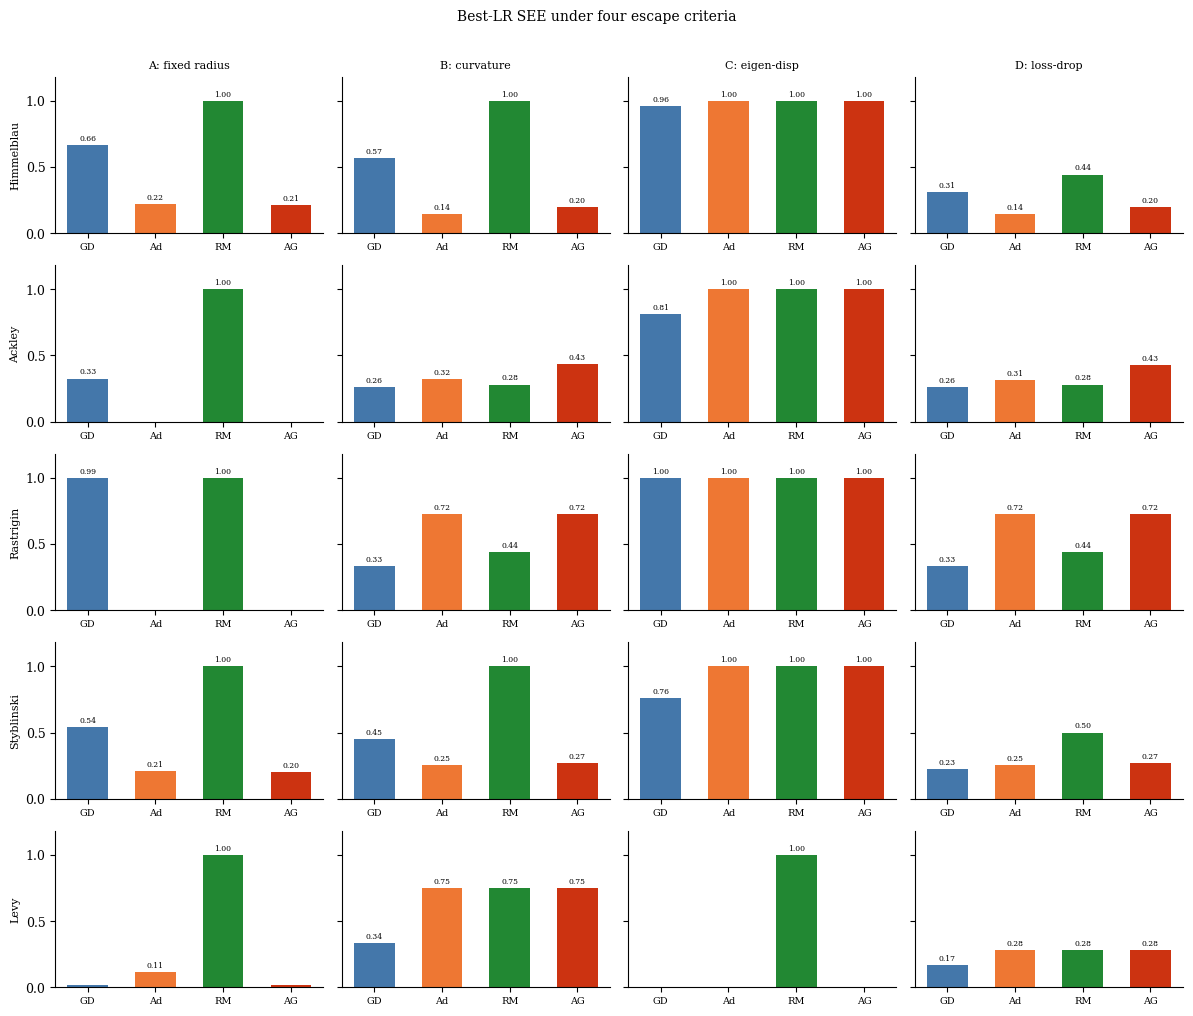

Saved fig1


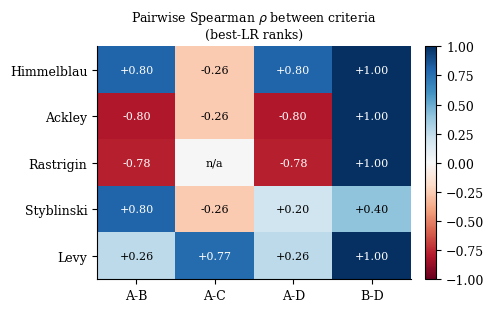

Saved fig2


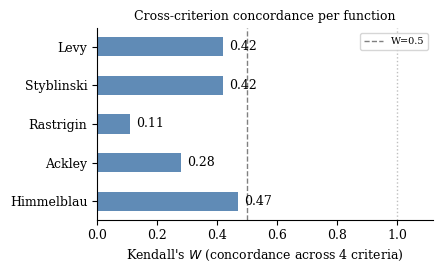

Saved fig3


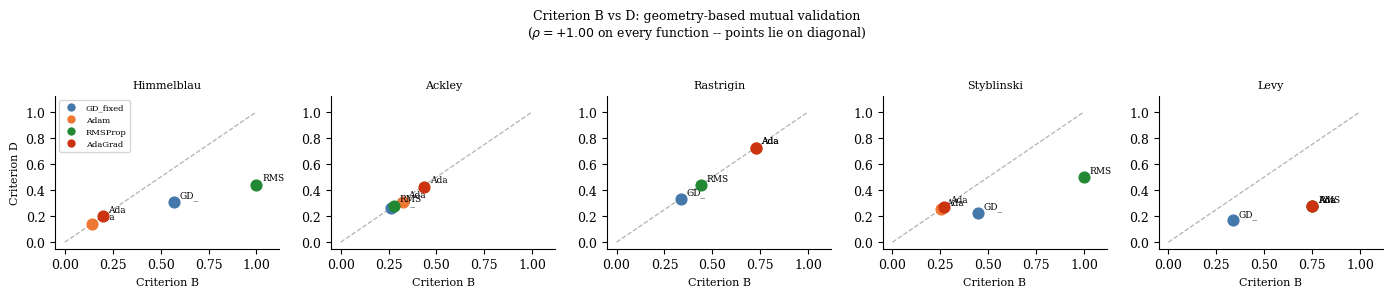

Saved fig4


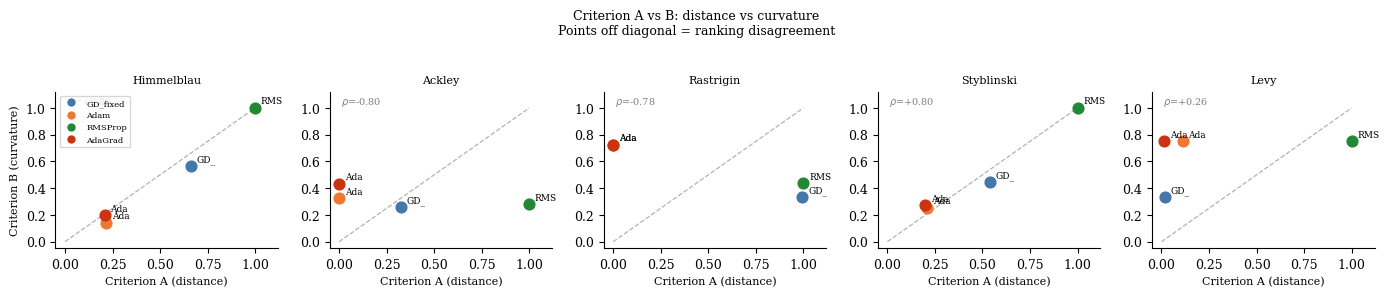

Saved fig5


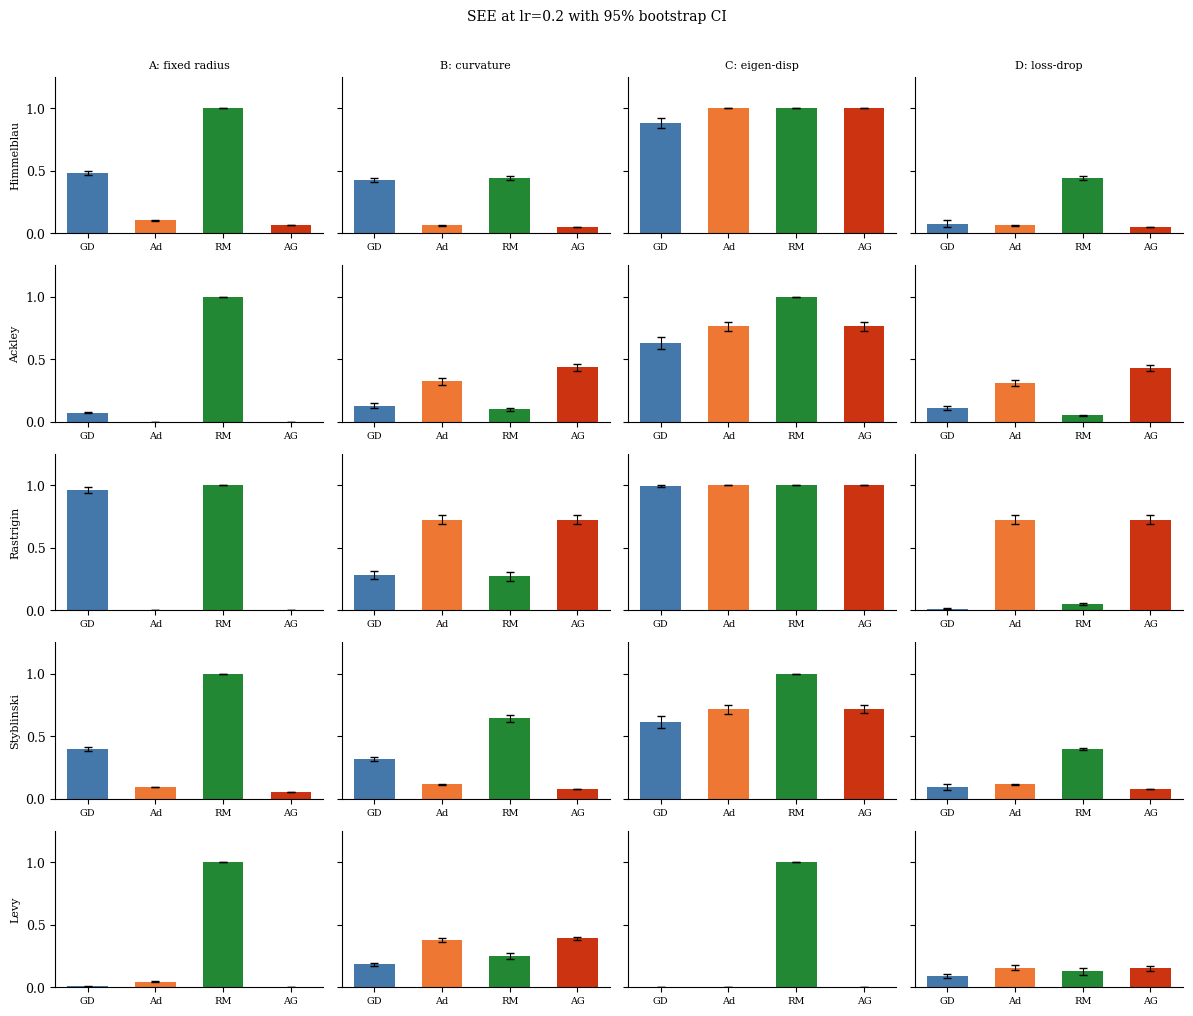

Saved fig6

All 6 figures saved to figures/
fig1_criteria_grid.png  -- bar chart best-LR all criteria
fig2_spearman_heatmap.png -- pairwise Spearman matrix
fig3_kendall_w.png      -- concordance per function
fig4_B_vs_D.png         -- mutual validation scatter
fig5_A_vs_B.png         -- ranking inversion scatter
fig6_lr02_with_CI.png   -- SEE at lr=0.2 with error bars


In [2]:
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 9
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
import matplotlib.pyplot as plt
from scipy import stats
import os
os.makedirs('figures', exist_ok=True)

FUNCS = ['Himmelblau', 'Ackley', 'Rastrigin', 'Styblinski', 'Levy']
OPTS  = ['GD_fixed', 'Adam', 'RMSProp', 'AdaGrad']
FAMS  = ['A', 'B', 'C', 'D']
CRIT  = {'A':'A: fixed radius','B':'B: curvature',
         'C':'C: eigen-disp','D':'D: loss-drop'}
colors = {'GD_fixed':'#4477aa','Adam':'#ee7733',
          'RMSProp':'#228833','AdaGrad':'#cc3311'}

# best-LR SEE [function][optimizer][criterion]
BEST = {
  'Himmelblau': {
    'GD_fixed': [0.662, 0.568, 0.957, 0.312],
    'Adam':     [0.218, 0.141, 1.000, 0.141],
    'RMSProp':  [1.000, 1.000, 1.000, 0.442],
    'AdaGrad':  [0.209, 0.198, 1.000, 0.198]},
  'Ackley': {
    'GD_fixed': [0.325, 0.262, 0.813, 0.262],
    'Adam':     [0.001, 0.323, 1.000, 0.312],
    'RMSProp':  [1.000, 0.280, 1.000, 0.280],
    'AdaGrad':  [0.000, 0.435, 1.000, 0.426]},
  'Rastrigin': {
    'GD_fixed': [0.995, 0.334, 1.000, 0.334],
    'Adam':     [0.000, 0.725, 1.000, 0.725],
    'RMSProp':  [1.000, 0.439, 1.000, 0.439],
    'AdaGrad':  [0.000, 0.725, 1.000, 0.725]},
  'Styblinski': {
    'GD_fixed': [0.541, 0.448, 0.763, 0.226],
    'Adam':     [0.209, 0.253, 1.000, 0.253],
    'RMSProp':  [1.000, 1.000, 1.000, 0.500],
    'AdaGrad':  [0.200, 0.271, 1.000, 0.271]},
  'Levy': {
    'GD_fixed': [0.019, 0.336, 0.000, 0.168],
    'Adam':     [0.112, 0.752, 0.000, 0.278],
    'RMSProp':  [1.000, 0.752, 1.000, 0.278],
    'AdaGrad':  [0.014, 0.752, 0.000, 0.278]},
}

# SEE at lr=0.2 [function][optimizer] = [A, B, C, D]
LR02 = {
  'Himmelblau': {
    'GD_fixed': [0.478, 0.422, 0.881, 0.075],
    'Adam':     [0.102, 0.064, 1.000, 0.064],
    'RMSProp':  [1.000, 0.442, 1.000, 0.442],
    'AdaGrad':  [0.062, 0.050, 1.000, 0.050]},
  'Ackley': {
    'GD_fixed': [0.073, 0.129, 0.629, 0.110],
    'Adam':     [0.000, 0.323, 0.763, 0.312],
    'RMSProp':  [1.000, 0.100, 1.000, 0.051],
    'AdaGrad':  [0.000, 0.435, 0.763, 0.426]},
  'Rastrigin': {
    'GD_fixed': [0.962, 0.280, 0.995, 0.012],
    'Adam':     [0.000, 0.725, 1.000, 0.725],
    'RMSProp':  [1.000, 0.271, 1.000, 0.052],
    'AdaGrad':  [0.000, 0.725, 1.000, 0.725]},
  'Styblinski': {
    'GD_fixed': [0.398, 0.316, 0.612, 0.094],
    'Adam':     [0.095, 0.115, 0.717, 0.115],
    'RMSProp':  [1.000, 0.643, 1.000, 0.398],
    'AdaGrad':  [0.052, 0.077, 0.717, 0.077]},
  'Levy': {
    'GD_fixed': [0.007, 0.186, 0.000, 0.091],
    'Adam':     [0.046, 0.381, 0.000, 0.158],
    'RMSProp':  [1.000, 0.251, 1.000, 0.127],
    'AdaGrad':  [0.003, 0.391, 0.000, 0.154]},
}

# CI at lr=0.2 [function][optimizer] = [A, B, C, D]
CI02 = {
  'Himmelblau': {
    'GD_fixed': [0.015, 0.017, 0.041, 0.027],
    'Adam':     [0.001, 0.003, 0.000, 0.003],
    'RMSProp':  [0.000, 0.015, 0.000, 0.014],
    'AdaGrad':  [0.000, 0.000, 0.000, 0.000]},
  'Ackley': {
    'GD_fixed': [0.007, 0.017, 0.048, 0.014],
    'Adam':     [0.000, 0.026, 0.036, 0.023],
    'RMSProp':  [0.000, 0.011, 0.000, 0.006],
    'AdaGrad':  [0.000, 0.026, 0.038, 0.024]},
  'Rastrigin': {
    'GD_fixed': [0.025, 0.033, 0.007, 0.002],
    'Adam':     [0.000, 0.036, 0.000, 0.035],
    'RMSProp':  [0.000, 0.037, 0.000, 0.007],
    'AdaGrad':  [0.000, 0.035, 0.000, 0.034]},
  'Styblinski': {
    'GD_fixed': [0.013, 0.015, 0.048, 0.025],
    'Adam':     [0.001, 0.002, 0.036, 0.002],
    'RMSProp':  [0.000, 0.029, 0.000, 0.011],
    'AdaGrad':  [0.000, 0.002, 0.035, 0.002]},
  'Levy': {
    'GD_fixed': [0.001, 0.012, 0.000, 0.013],
    'Adam':     [0.006, 0.016, 0.000, 0.020],
    'RMSProp':  [0.000, 0.024, 0.000, 0.031],
    'AdaGrad':  [0.000, 0.015, 0.000, 0.020]},
}

SPEARMAN = {
  'Himmelblau': {'AB':+0.80,'AC':-0.26,'AD':+0.80,'BD':+1.00},
  'Ackley':     {'AB':-0.80,'AC':-0.26,'AD':-0.80,'BD':+1.00},
  'Rastrigin':  {'AB':-0.78,'AC': None,'AD':-0.78,'BD':+1.00},
  'Styblinski': {'AB':+0.80,'AC':-0.26,'AD':+0.20,'BD':+0.40},
  'Levy':       {'AB':+0.26,'AC':+0.77,'AD':+0.26,'BD':+1.00},
}

KENDALL_W = {
  'Himmelblau': 0.47,
  'Ackley':     0.28,
  'Rastrigin':  0.11,
  'Styblinski': 0.42,
  'Levy':       0.42,
}

# ── Fig 1: criteria grid bar chart ──────────────────────────────
fig, axes = plt.subplots(len(FUNCS), 4,
    figsize=(12, 2.0*len(FUNCS)), squeeze=False)
for i, fn in enumerate(FUNCS):
    for j, fam in enumerate(FAMS):
        ax = axes[i, j]
        fi = FAMS.index(fam)
        vals = [BEST[fn][o][fi] for o in OPTS]
        bars = ax.bar(range(4), vals,
            color=[colors[o] for o in OPTS], width=0.6)
        ax.set_xticks(range(4))
        ax.set_xticklabels(['GD','Ad','RM','AG'], fontsize=7)
        ax.set_ylim(0, 1.18)
        ax.set_yticks([0, 0.5, 1.0])
        if j == 0:
            ax.set_ylabel(fn, fontsize=8)
        else:
            ax.set_yticklabels([])
        if i == 0:
            ax.set_title(CRIT[fam], fontsize=8)
        for bar, v in zip(bars, vals):
            if v > 0.08:
                ax.text(bar.get_x()+bar.get_width()/2,
                    v+0.02, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=5.5)
plt.suptitle('Best-LR SEE under four escape criteria', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig1_criteria_grid.png', dpi=300, bbox_inches='tight')
plt.show(); print('Saved fig1')

# ── Fig 2: Spearman heatmap ──────────────────────────────────────
pairs = ['AB','AC','AD','BD']
pair_labels = ['A-B','A-C','A-D','B-D']
M = np.zeros((len(FUNCS), len(pairs)))
for i, fn in enumerate(FUNCS):
    for j, p in enumerate(pairs):
        v = SPEARMAN[fn][p]
        M[i, j] = v if v is not None else 0.0

fig, ax = plt.subplots(figsize=(5, 3.2))
im = ax.imshow(M, vmin=-1, vmax=1, cmap='RdBu', aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(pair_labels, fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(FUNCS, fontsize=9)
for i in range(len(FUNCS)):
    for j in range(len(pairs)):
        v = SPEARMAN[FUNCS[i]][pairs[j]]
        txt = 'n/a' if v is None else f'{v:+.2f}'
        col = 'white' if (v is not None and abs(v) > 0.6) else 'black'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=8, color=col)
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Pairwise Spearman $\\rho$ between criteria\n(best-LR ranks)', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig2_spearman_heatmap.png', dpi=300, bbox_inches='tight')
plt.show(); print('Saved fig2')

# ── Fig 3: Kendall W bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 2.8))
Ws = [KENDALL_W[fn] for fn in FUNCS]
bars = ax.barh(FUNCS, Ws, color='#4477aa', alpha=0.85, height=0.5)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='W=0.5')
ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Kendall's $W$ (concordance across 4 criteria)")
ax.set_title("Cross-criterion concordance per function", fontsize=9)
for bar, w in zip(bars, Ws):
    ax.text(w+0.02, bar.get_y()+bar.get_height()/2,
            f'{w:.2f}', va='center', fontsize=9)
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('figures/fig3_kendall_w.png', dpi=300, bbox_inches='tight')
plt.show(); print('Saved fig3')

# ── Fig 4: B vs D scatter (mutual validation) ────────────────────
fig, axes = plt.subplots(1, len(FUNCS),
    figsize=(2.8*len(FUNCS), 2.8), squeeze=False)
for i, fn in enumerate(FUNCS):
    ax = axes[0, i]
    for o in OPTS:
        bv = BEST[fn][o][1]
        dv = BEST[fn][o][3]
        ax.scatter(bv, dv, color=colors[o], s=60, zorder=3)
        ax.annotate(o[:3], (bv, dv),
            textcoords='offset points', xytext=(4,3), fontsize=6.5)
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=0.9,alpha=0.6)
    ax.set_xlim(-0.05, 1.12); ax.set_ylim(-0.05, 1.12)
    ax.set_xlabel('Criterion B', fontsize=8)
    if i == 0: ax.set_ylabel('Criterion D', fontsize=8)
    ax.set_title(fn, fontsize=8)
handles = [plt.Line2D([0],[0],marker='o',color='w',
    markerfacecolor=colors[o],markersize=7,label=o) for o in OPTS]
axes[0,0].legend(handles=handles, fontsize=6, loc='upper left')
plt.suptitle('Criterion B vs D: geometry-based mutual validation\n'
    '($\\rho=+1.00$ on every function -- points lie on diagonal)',
    fontsize=9, y=1.04)
plt.tight_layout()
plt.savefig('figures/fig4_B_vs_D.png', dpi=300, bbox_inches='tight')
plt.show(); print('Saved fig4')

# ── Fig 5: A vs B scatter (ranking inversion) ────────────────────
fig, axes = plt.subplots(1, len(FUNCS),
    figsize=(2.8*len(FUNCS), 2.8), squeeze=False)
for i, fn in enumerate(FUNCS):
    ax = axes[0, i]
    for o in OPTS:
        av = BEST[fn][o][0]
        bv = BEST[fn][o][1]
        ax.scatter(av, bv, color=colors[o], s=60, zorder=3)
        ax.annotate(o[:3], (av, bv),
            textcoords='offset points', xytext=(4,3), fontsize=6.5)
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=0.9,alpha=0.6)
    ax.set_xlim(-0.05, 1.12); ax.set_ylim(-0.05, 1.12)
    ax.set_xlabel('Criterion A (distance)', fontsize=8)
    if i == 0: ax.set_ylabel('Criterion B (curvature)', fontsize=8)
    ax.set_title(fn, fontsize=8)
    rho = SPEARMAN[fn]['AB']
    rho_str = 'n/a' if rho is None else f'{rho:+.2f}'
    ax.text(0.05, 0.92, f'$\\rho$={rho_str}',
        transform=ax.transAxes, fontsize=7, color='gray')
handles = [plt.Line2D([0],[0],marker='o',color='w',
    markerfacecolor=colors[o],markersize=7,label=o) for o in OPTS]
axes[0,0].legend(handles=handles, fontsize=6, loc='upper left')
plt.suptitle('Criterion A vs B: distance vs curvature\n'
    'Points off diagonal = ranking disagreement',
    fontsize=9, y=1.04)
plt.tight_layout()
plt.savefig('figures/fig5_A_vs_B.png', dpi=300, bbox_inches='tight')
plt.show(); print('Saved fig5')

# ── Fig 6: SEE at lr=0.2 with CI bars ───────────────────────────
fig, axes = plt.subplots(len(FUNCS), 4,
    figsize=(12, 2.0*len(FUNCS)), squeeze=False)
x = np.arange(4); w = 0.6
for i, fn in enumerate(FUNCS):
    for j, fam in enumerate(FAMS):
        ax = axes[i, j]
        fi = FAMS.index(fam)
        vals = np.array([LR02[fn][o][fi] for o in OPTS])
        cis  = np.array([CI02[fn][o][fi] for o in OPTS])
        bars = ax.bar(x, vals,
            color=[colors[o] for o in OPTS],
            width=w, yerr=cis, capsize=3,
            error_kw={'linewidth':0.8})
        ax.set_xticks(x)
        ax.set_xticklabels(['GD','Ad','RM','AG'], fontsize=7)
        ax.set_ylim(0, 1.25)
        ax.set_yticks([0, 0.5, 1.0])
        if j == 0:
            ax.set_ylabel(fn, fontsize=8)
        else:
            ax.set_yticklabels([])
        if i == 0:
            ax.set_title(CRIT[fam], fontsize=8)
plt.suptitle('SEE at lr=0.2 with 95% bootstrap CI', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig6_lr02_with_CI.png', dpi=300, bbox_inches='tight')
plt.show(); print('Saved fig6')

print('\nAll 6 figures saved to figures/')
print('fig1_criteria_grid.png  -- bar chart best-LR all criteria')
print('fig2_spearman_heatmap.png -- pairwise Spearman matrix')
print('fig3_kendall_w.png      -- concordance per function')
print('fig4_B_vs_D.png         -- mutual validation scatter')
print('fig5_A_vs_B.png         -- ranking inversion scatter')
print('fig6_lr02_with_CI.png   -- SEE at lr=0.2 with error bars')